In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import nltk
import warnings
import seaborn as sns
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from matplotlib.ticker import MaxNLocator
from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.preprocessing import StandardScaler
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [ ]:
#Mounting Drive and Initial Load of the Data for Modeling.
drive.mount('/content/drive')

articles_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MAP6114 - Machine Learning/MAP 6114 Project/Model_Cheyanne/articles.csv")
print(articles_df.columns.tolist())

alerts_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/MAP6114 - Machine Learning/MAP 6114 Project/Kristi's Workflow/Deliverable Files/normalized_weekly_alerts.csv")
print(alerts_df.columns.tolist())

MessageError: Error: credential propagation was unsuccessful

## **Data Visualization**

In [ ]:
display(articles_df.head())
display(alerts_df.head())

NameError: name 'articles_df' is not defined

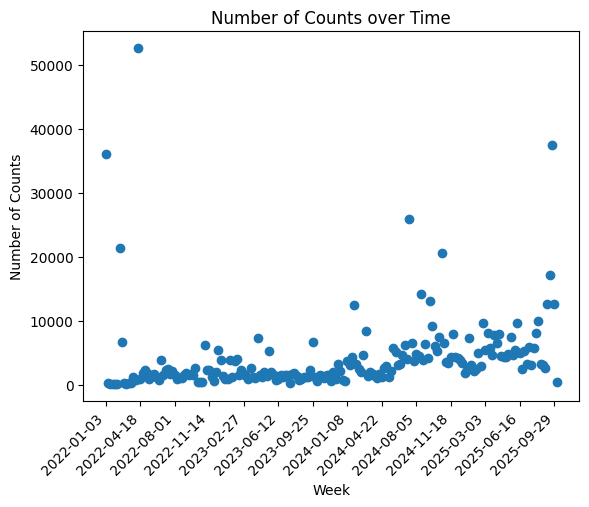

In [ ]:
plt.scatter(alerts_df['WEEK'], alerts_df['NUM_ALERTS'])
plt.xlabel('Week')
plt.ylabel('Number of Counts')
# Get the current axes
ax = plt.gca()
# Set the maximum number of ticks you want visible on the x-axis
n_ticks_to_show = 20
ax.xaxis.set_major_locator(MaxNLocator(n_ticks_to_show))
plt.xticks(rotation=45, ha='right')
plt.title('Number of Counts over Time')
plt.show()

## **Baseline Model**

The model below serves as a baseline, using the previous three weeks to forecast the range of counts for the subsequent fourth week.

Given all of the current data, the accuracy using this method is ~ 60.8%

In [ ]:
baseline_alerts_df = alerts_df.copy()
baseline_alerts_df['bucket'].value_counts()

,count
bucket,
low,101
average,70
high,22
very_high,4


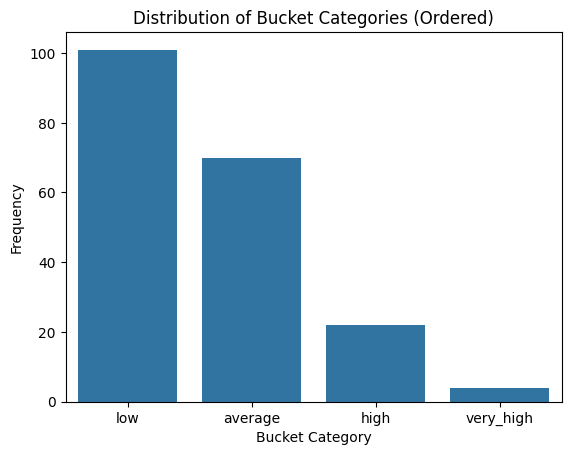

In [ ]:
category_order = ['low', 'average', 'high', 'very_high']
baseline_alerts_df['bucket_ordered'] = pd.Categorical(
    baseline_alerts_df['bucket'],
    categories=category_order,
    ordered=True
)

# Use seaborn.countplot for better visualization of ordered categorical data
sns.countplot(x='bucket_ordered', data=baseline_alerts_df, order=category_order)
plt.xlabel('Bucket Category')
plt.ylabel('Frequency')
plt.title('Distribution of Bucket Categories (Ordered)')
plt.show()

In [ ]:
# Encoding the buckets
bucket_map = {'low':0, 'average':1, 'high': 2, 'very_high':3}
baseline_alerts_df['bucket_encoded'] = baseline_alerts_df['bucket'].map(bucket_map)

In [ ]:
# Calculate the rolling sum over a 3-week window
# min_periods=3 ensures we only calculate where we have 3 weeks of data
baseline_alerts_df['three_week_sum'] = baseline_alerts_df['bucket_encoded'].rolling(window=3, min_periods=3).sum()

# Calculate the average and round to the nearest whole number
baseline_alerts_df['avg_3wk_rounded'] = np.round(baseline_alerts_df['three_week_sum'] / 3)

# Shift the averages by 1 week
baseline_alerts_df['avg_3wk_shifted'] = baseline_alerts_df['avg_3wk_rounded'].shift(1)

display(baseline_alerts_df)

,WEEK,NUM_ALERTS,log_alerts,bucket,bucket_encoded,three_week_sum,avg_3wk_rounded,avg_3wk_shifted
0,2022-01-03,36127,10.494823,very_high,3,NaN,NaN,NaN
1,2022-01-10,200,5.303305,low,0,NaN,NaN,NaN
2,2022-01-17,90,4.510860,low,0,3.0,1.0,NaN
3,2022-01-24,165,5.111988,low,0,0.0,0.0,1.0
4,2022-01-31,106,4.672829,low,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
192,2025-09-08,12532,9.436120,high,2,4.0,1.0,1.0
193,2025-09-15,17217,9.753711,high,2,5.0,2.0,1.0
194,2025-09-22,37557,10.533642,very_high,3,7.0,2.0,2.0
195,2025-09-29,12626,9.443593,high,2,7.0,2.0,2.0


In [ ]:
baseline_alerts_df[['WEEK', 'bucket', 'bucket_encoded', 'avg_3wk_rounded', 'avg_3wk_shifted']].head()

,WEEK,bucket,bucket_encoded,avg_3wk_rounded,avg_3wk_shifted
0,2022-01-03,very_high,3,NaN,NaN
1,2022-01-10,low,0,NaN,NaN
2,2022-01-17,low,0,1.0,NaN
3,2022-01-24,low,0,0.0,1.0
4,2022-01-31,low,0,0.0,0.0


In [ ]:
# Drop rows which don't have a complete 3-week rolling average period.
final_feature_df = baseline_alerts_df.dropna(subset='avg_3wk_shifted')
final_feature_df = final_feature_df.drop(columns=['NUM_ALERTS', 'log_alerts', 'three_week_sum', 'avg_3wk_rounded'])

final_feature_df['shifted_buckets_match'] = (final_feature_df['bucket_encoded'] == final_feature_df['avg_3wk_shifted']).astype(int)

display(final_feature_df.head())

,WEEK,bucket,bucket_encoded,avg_3wk_shifted,shifted_buckets_match
3,2022-01-24,low,0,1.0,0
4,2022-01-31,low,0,0.0,1
5,2022-02-07,low,0,0.0,1
6,2022-02-14,high,2,0.0,0
7,2022-02-21,average,1,1.0,1


In [ ]:
final_feature_df['shifted_buckets_match'].mean()

np.float64(0.6082474226804123)

#### **Alternative Baseline Model**

The model below shifts the target buckets by one week and compares whether or not the range of counts in one week can help predict the general range of counts in the following week.

In [ ]:
alerts_df['bucket_next_week'] = alerts_df['bucket'].shift(-1)
alerts_df['do_buckets_match'] = (alerts_df['bucket'] == alerts_df['bucket_next_week']).astype(int)

In [ ]:
alerts_df['do_buckets_match'].mean()

np.float64(0.6243654822335025)

## **Training and Evaluation Functions**

In [ ]:
def prepare_tfidf_data(articles_df_input, alerts_df_input, vectorizer, lemmatize_func=None, keyword_corrections=None, model_name=""):
    articles_df_local = articles_df_input.copy()
    alerts_df_local = alerts_df_input.copy()

    # Ensure 'keywords' column is in list format if not already
    # Only apply ast.literal_eval if the element is a string. This ensures idempotency.
    articles_df_local['keywords'] = articles_df_local['keywords'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

    # Combine ALL the keywords into a weekly string, all joined together
    keywords_by_week_list = (
        articles_df_local
            .groupby('week_start')['keywords']
            .apply(lambda x: sum(x, []))
            .reset_index(name='combined_keywords_list')
    )

    if lemmatize_func:
        print(f"Applying lemmatization for {model_name}...")
        keywords_by_week_list['processed_keywords_string'] = (
            keywords_by_week_list['combined_keywords_list']
            .apply(lambda x: lemmatize_func(x, keyword_corrections))
            .apply(lambda x: ' '.join(x))
        )
        keywords_col_name = 'processed_keywords_string'
    else:
        print(f"No lemmatization for {model_name}...")
        keywords_by_week_list['processed_keywords_string'] = (
            keywords_by_week_list['combined_keywords_list']
            .apply(lambda x: ' '.join(x))
        )
        keywords_col_name = 'processed_keywords_string'

    # Fit TF-IDF and transform the combined keywords
    tfidf_matrix = vectorizer.fit_transform(keywords_by_week_list[keywords_col_name])

    # Create the final DataFrame for inspection
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=vectorizer.get_feature_names_out()
    )

    tfidf_df.insert(0, 'week_start', keywords_by_week_list['week_start'].values)
    print(f"TF-IDF Matrix Shape ({model_name}): {tfidf_matrix.shape}")

    # Make sure that the week columns match in both the feature matrices and the alerts file
    alerts_df_local['WEEK'] = pd.to_datetime(alerts_df_local['WEEK'])
    tfidf_df['week_start'] = pd.to_datetime(tfidf_df['week_start'])

    # Alerts weeks not in TF-IDF (to add zero-vectors for missing weeks)
    missing_in_tfidf = alerts_df_local[~alerts_df_local['WEEK'].isin(tfidf_df['week_start'])]

    # Create Placeholders for missing features
    tfidf_cols = vectorizer.get_feature_names_out()
    placeholders = pd.DataFrame(
        0,
        index=np.arange(len(missing_in_tfidf)),
        columns=tfidf_cols
    )
    placeholders['week_start'] = missing_in_tfidf['WEEK'].values

    # Append to the TF-IDF dataframe
    tfidf_df = pd.concat([tfidf_df, placeholders], ignore_index=True)

    # Sort by week_start
    tfidf_df = tfidf_df.sort_values('week_start').reset_index(drop=True)

    #Combine Feature tfidf_df and alerts_df
    model_df = tfidf_df.merge(
        alerts_df_local,
        left_on='week_start',
        right_on='WEEK',
        how='right'
    )

    #Drop WEEK column--Now Unnecessary
    model_df = model_df.drop(columns=['WEEK'])

    #Make sure everything is still in chronological order
    model_df = model_df.sort_values('week_start').reset_index(drop=True)

    print(f"Final Model DataFrame Shape ({model_name}): {model_df.shape}")
    return model_df, tfidf_cols

In [ ]:
def create_lagged_columns(model_df_input, tfidf_cols,lag_periods):
  model_df = model_df_input.copy()

  # Step 1: Create lagged features
  lags = list(range(1, lag_periods+1))
  lagged_frames = []

  for lag in lags:
      # Shift all TF-IDF columns at once
      shifted = model_df[tfidf_cols].shift(lag)
      shifted.columns = [f"{col}_lag{lag}" for col in tfidf_cols]
      lagged_frames.append(shifted)

  # Concatenate lagged columns to the original DataFrame
  model_df = pd.concat([model_df] + lagged_frames, axis=1)

  # Fill NaNs in lagged features (first 3 weeks) with zeros
  lag_cols = [col for col in model_df.columns if '_lag' in col]
  model_df[lag_cols] = model_df[lag_cols].fillna(0)

  return model_df, lag_cols

In [ ]:
def create_train_test_split(model_df_input, lag_columns, model_name):
  model_df = model_df_input.copy()

  # Chronological 80/20 train/test split
  num_rows = len(model_df)
  split_idx = int(num_rows * 0.8)

  train_df = model_df.iloc[:split_idx]
  test_df  = model_df.iloc[split_idx:]

  X_train = train_df[lag_columns].values
  y_train = train_df['bucket'].values

  X_test = test_df[lag_columns].values
  y_test = test_df['bucket'].values

  print(f"Train shape ({model_name}): {X_train.shape} {y_train.shape}")
  print(f"Test shape ({model_name}):  {X_test.shape} {y_test.shape}")

  return train_df, test_df, X_train, y_train, X_test, y_test

In [ ]:
def prepare_lagged_split_model(model_df_input, tfidf_cols, lag_periods, model_name):
  model_df, lag_cols = create_lagged_columns(model_df_input, tfidf_cols, lag_periods)
  train_df, test_df, X_train, y_train, X_test, y_test = create_train_test_split(model_df, lag_cols, model_name)
  return train_df, test_df, X_train, y_train, X_test, y_test

In [ ]:
def fit_model(X_train, y_train, pipeline):
  fitted_model = pipeline.fit(X_train, y_train)
  return fitted_model

In [ ]:
def evaluate_model(pipeline, X_act, y_act, model_name, stage):
  y_pred = pipeline.predict(X_act)
  train_acc = accuracy_score(y_act, y_pred)
  f1_weighted_train = f1_score(y_act, y_pred, average='weighted')
  f1_macro_train = f1_score(y_act, y_pred, average='macro')

  print(f"--- {model_name} {stage} Set Results ---")
  print(f"F1-Weighted Score: {f1_weighted_train:.4f} (Primary Indicator)")
  print(f"F1-Macro Score:    {f1_macro_train:.4f} (Minority Class Performance)")
  print(f"Accuracy:          {train_acc:.4f} (Raw Correctness)")

  return y_pred

In [ ]:
def plot_predictions(model_df_input, y_act, y_pred, model_name, stage):
  plot_confusion_matrix(model_df_input, y_act, y_pred, model_name, stage)
  plot_line_graph(model_df_input, y_act, y_pred, model_name, stage)

In [ ]:
def plot_confusion_matrix(model_df_input, y_act, y_pred, model_name, stage):
  cm = confusion_matrix(y_act, y_pred, labels=np.unique(y_act))
  disp_test = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_act))
  disp_test.plot(cmap="Blues", xticks_rotation='vertical')
  plt.title(f"{stage} Confusion Matrix ({model_name})")
  plt.show()

In [ ]:
def plot_line_graph(model_df_input, y_act, y_pred, model_name, stage):
  plt.figure(figsize=(12,4))
  plt.plot(model_df_input['week_start'], y_act, marker='o', linestyle='-', label='Actual Bucket')
  plt.plot(model_df_input['week_start'], y_pred, marker='x', linestyle='--', label='Predicted Bucket')
  plt.xticks(rotation=45)
  plt.xlabel("Week")
  plt.ylabel("Bucket")
  plt.title(f"{stage}: Actual vs Predicted Buckets Over Time ({model_name})")
  plt.legend()
  plt.tight_layout()
  plt.show()

In [ ]:
def train_evaluate_model_2(train_df, test_df, X_train, y_train, X_test, y_test, pipeline, model_name, plots = True):
  model = fit_model(X_train, y_train, pipeline)
  # Evaluate and plot Training Data
  training_y_pred = evaluate_model(pipeline, X_train, y_train, model_name, stage='Training')
  if plots:
    plot_predictions(train_df, y_train, training_y_pred, model_name, stage='Training')

  # Evaluate and plot Testing Data
  testing_y_pred = evaluate_model(pipeline, X_test, y_test, model_name, stage='Testing')
  if plots:
    plot_predictions(test_df, y_test, testing_y_pred, model_name, stage='Testing')

  return model

## **Model Development**

In [ ]:
# Filter out the specific FutureWarning from sklearn.linear_model._logistic
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module='sklearn.linear_model._logistic'
)

print("FutureWarning from sklearn.linear_model._logistic has been silenced.")

FutureWarning from sklearn.linear_model._logistic has been silenced.


### **TF-IDF Vectorization, Logistic Regression - No Lemmatization**

In [ ]:
# Initialize the TF-IDF Vectorizer
vectorizer_no_lemma = TfidfVectorizer(
    stop_words='english',
    max_features=5000,          # Limits vocabulary size
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z-]{1,}[a-zA-Z]\b'
)

# Prepare the data using the helper function
model_df_no_lemma, tfidf_cols_no_lemma = prepare_tfidf_data(
    articles_df,
    alerts_df,
    vectorizer_no_lemma,
    model_name="No Lemmatization"
)

display(model_df_no_lemma.head())

No lemmatization for No Lemmatization...
TF-IDF Matrix Shape (No Lemmatization): (194, 5000)
Final Model DataFrame Shape (No Lemmatization): (197, 5006)


,week_start,abandon,abc,abcotv,abdul,ability,able,abramovich,abramovichs,abroad,...,zimbabweans,zimbabwes,zionist,zone,zones,NUM_ALERTS,log_alerts,bucket,bucket_next_week,do_buckets_match
0,2022-01-03,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,36127,10.494823,very_high,low,0
1,2022-01-10,0.022054,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.007837,0.0,0.0,0.0,200,5.303305,low,low,1
2,2022-01-17,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,90,4.510860,low,low,1
3,2022-01-24,0.000000,0.0,0.0,0.0,0.030445,0.008264,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,165,5.111988,low,low,1
4,2022-01-31,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,106,4.672829,low,low,1


Train shape (No Lemmatization): (157, 15000) (157,)
Test shape (No Lemmatization):  (40, 15000) (40,)
--- No Lemmatization Training Set Results ---
F1-Weighted Score: 0.8650 (Primary Indicator)
F1-Macro Score:    0.5633 (Minority Class Performance)
Accuracy:          0.8854 (Raw Correctness)


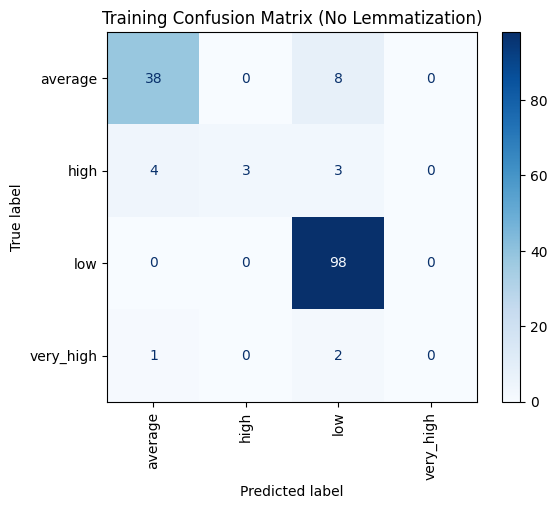

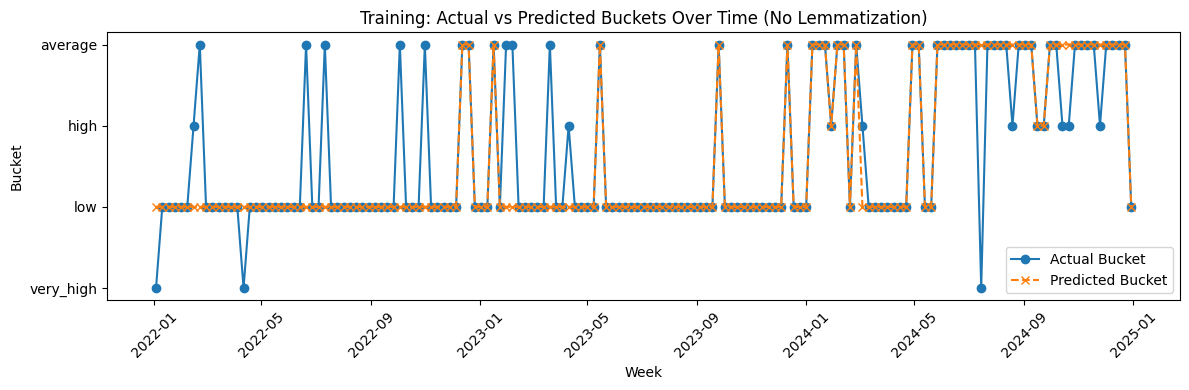

--- No Lemmatization Testing Set Results ---
F1-Weighted Score: 0.1586 (Primary Indicator)
F1-Macro Score:    0.0911 (Minority Class Performance)
Accuracy:          0.1500 (Raw Correctness)


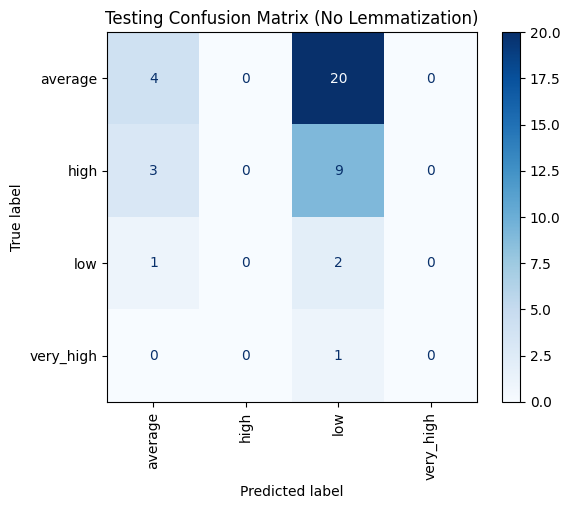

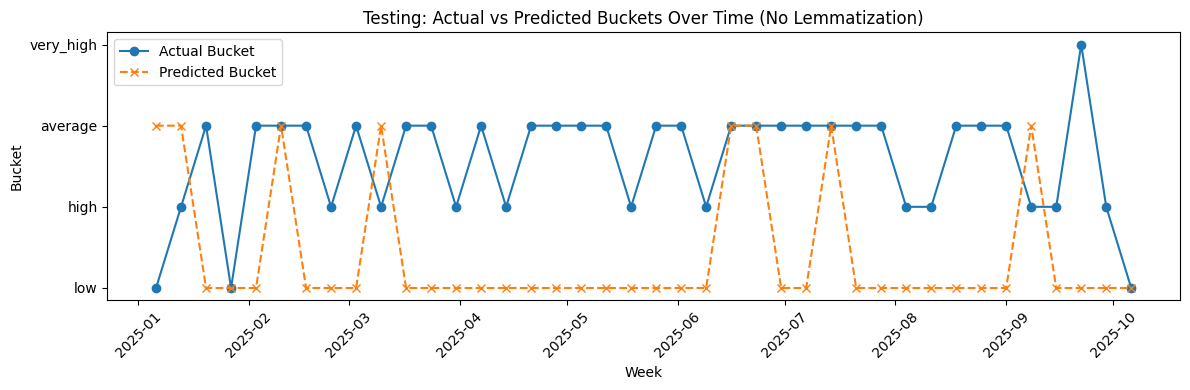

In [ ]:
# Fit multinomial logistic regression (No Lemmatization)
clf_no_lemma = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=500,
)

train_df_no_lemma, test_df_no_lemma, X_train_no_lemma, y_train_no_lemma, X_test_no_lemma, y_test_no_lemma = prepare_lagged_split_model(
    model_df_no_lemma,
    tfidf_cols_no_lemma,
    lag_periods=3,
    model_name = "No Lemmatization",
)

clf_no_lemma_trained = train_evaluate_model_2(
    train_df_no_lemma,
    test_df_no_lemma,
    X_train_no_lemma,
    y_train_no_lemma,
    X_test_no_lemma,
    y_test_no_lemma,
    clf_no_lemma,
    model_name="No Lemmatization",
    plots=True
)


### **TF-IDF Vectorization, Logistic Regression - Lemmatization**

In [ ]:
keyword_corrections = {
    'abramovichs': 'abramovich',
    'zelenskyys': 'zelensky',
    'zelenskyy': 'zelensky',
    'zelenskys': 'zelensky',
    'zelenskiy': 'zelensky',
    'zimbabwean': 'zimbabwe',
    'zimbabweans': 'zimbabwe',
    'zimbabwes': 'zimbabwe',
    'afghanistans': 'afghanistan',
    'africas': 'africa',
}

In [ ]:
# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

def normalize_keywords_refined_wrapper(keyword_list, corrections):
    """
    Wrapper function to pass keyword_corrections to normalize_keywords_refined.
    """
    normalized_list = []
    for word in keyword_list:
        # Apply custom mapping first (and lowercase)
        mapped_word = corrections.get(word.lower(), word.lower())

        # Apply Lemmatization
        # This handles standard verb tenses AND standard plurals/nouns.
        lemma = lemmatizer.lemmatize(mapped_word, wordnet.VERB)

        normalized_list.append(lemma)

    return normalized_list

# Apply the TF-IDF Vectorizer to the lemmatized column
vectorizer_lemma = TfidfVectorizer(
    stop_words='english',
    max_features=5000,          # Limits vocabulary size to 5000 base words
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z-]{1,}[a-zA-Z]\b'
)

# Prepare the data using the helper function with lemmatization
model_df_lemma, tfidf_cols_lemma = prepare_tfidf_data(
    articles_df,
    alerts_df,
    vectorizer_lemma,
    lemmatize_func=normalize_keywords_refined_wrapper,
    keyword_corrections=keyword_corrections,
    model_name="Lemmatization"
)

print("\nExample of Lemmatized Vocabulary:")
print(vectorizer_lemma.get_feature_names_out()[:100])

display(model_df_lemma.head())

Applying lemmatization for Lemmatization...
TF-IDF Matrix Shape (Lemmatization): (194, 5000)
Final Model DataFrame Shape (Lemmatization): (197, 5006)

Example of Lemmatized Vocabulary:
['abandon' 'abc' 'abcotv' 'abdul' 'ability' 'able' 'abramovich' 'abroad'
 'absolutely' 'abstain' 'absurd' 'abuse' 'abusers' 'abusive' 'accelerate'
 'accept' 'access' 'accession' 'accord' 'account' 'accountability'
 'accountable' 'accountants' 'accusations' 'accuse' 'achieve'
 'acknowledge' 'acquire' 'act' 'action' 'active' 'activist' 'activists'
 'activities' 'activity' 'actors' 'actually' 'adani' 'adapt'
 'adaptability' 'adaptation' 'add' 'additional' 'address' 'adeyemo'
 'adjust' 'admin' 'administration' 'administrations' 'administrative'
 'admit' 'adopt' 'adoption' 'ads' 'advance' 'advantage' 'adversaries'
 'adverse' 'advertisementadvertisement' 'advice' 'advise' 'adviser'
 'advisor' 'advisory' 'advocate' 'aeoi' 'aeroflot' 'aerospace' 'affairs'
 'affect' 'affiliate' 'affirm' 'afghan' 'afghanistan' 'af

,week_start,abandon,abc,abcotv,abdul,ability,able,abramovich,abroad,absolutely,...,zim,zimbabwe,zionist,zone,zvezda,NUM_ALERTS,log_alerts,bucket,bucket_next_week,do_buckets_match
0,2022-01-03,0.000000,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,36127,10.494823,very_high,low,0
1,2022-01-10,0.016971,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.009079,0.0,0.0,0.0,200,5.303305,low,low,1
2,2022-01-17,0.000000,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.009701,0.0,0.0,0.0,90,4.510860,low,low,1
3,2022-01-24,0.000000,0.0,0.0,0.0,0.03046,0.008268,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,165,5.111988,low,low,1
4,2022-01-31,0.000000,0.0,0.0,0.0,0.00000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,106,4.672829,low,low,1


Train shape (Lemmatization): (157, 15000) (157,)
Test shape (Lemmatization):  (40, 15000) (40,)
--- Lemmatization Training Set Results ---
F1-Weighted Score: 0.8540 (Primary Indicator)
F1-Macro Score:    0.5289 (Minority Class Performance)
Accuracy:          0.8790 (Raw Correctness)


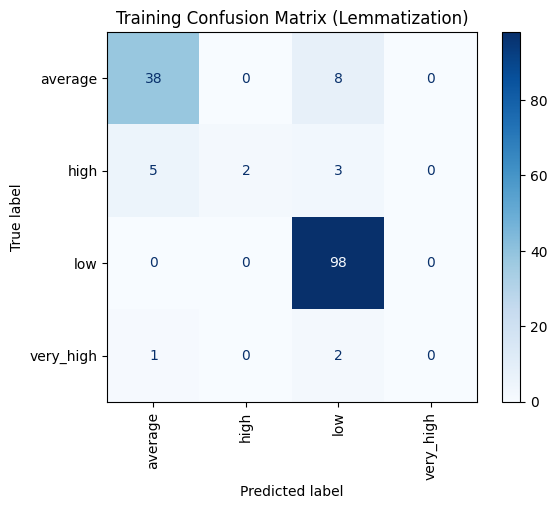

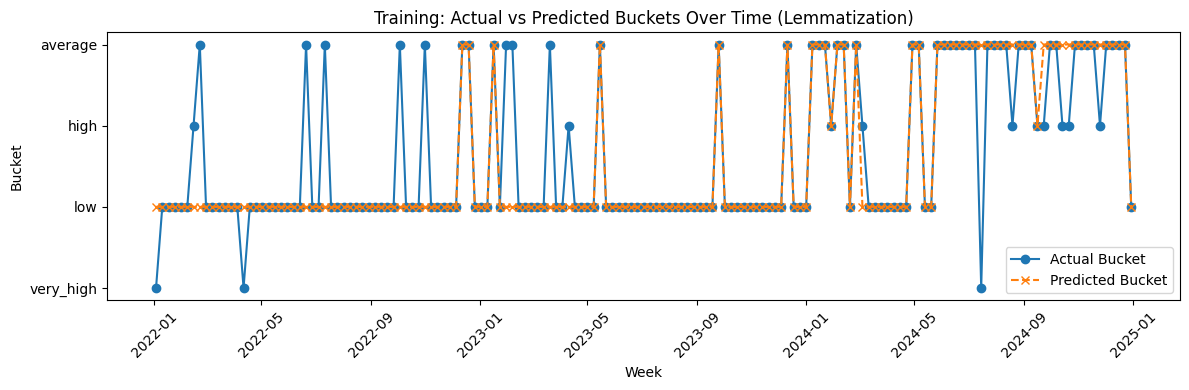

--- Lemmatization Testing Set Results ---
F1-Weighted Score: 0.2494 (Primary Indicator)
F1-Macro Score:    0.1313 (Minority Class Performance)
Accuracy:          0.2250 (Raw Correctness)


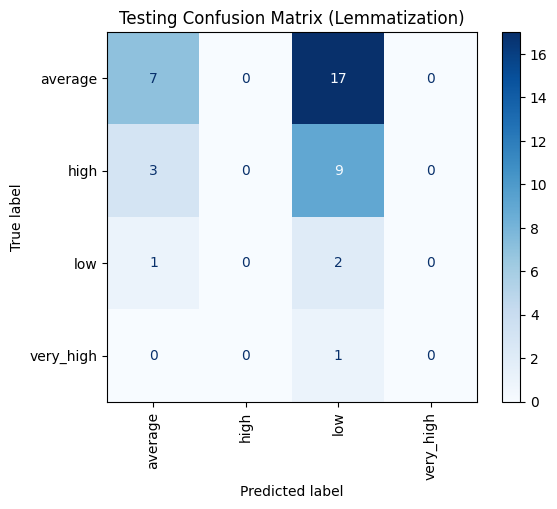

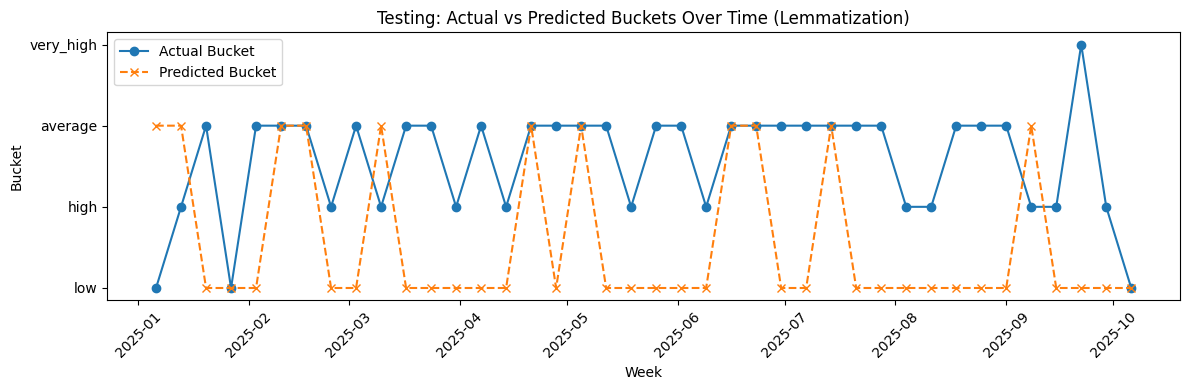

In [ ]:
# Fit multinomial logistic regression (Lemmatization)
clf_lemma = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=500
)

train_df_lemma, test_df_lemma, X_train_lemma, y_train_lemma, X_test_lemma, y_test_lemma = prepare_lagged_split_model(
    model_df_lemma,
    tfidf_cols_lemma,
    lag_periods=3,
    model_name = "Lemmatization",
)

clf_no_lemma_trained = train_evaluate_model_2(
    train_df_lemma,
    test_df_lemma,
    X_train_lemma,
    y_train_lemma,
    X_test_lemma,
    y_test_lemma,
    clf_lemma,
    model_name="Lemmatization",
    plots=True
)

In [ ]:
print(y_train_lemma.shape)
print(X_train_lemma.shape)

print(y_test_lemma.shape)
print(X_test_lemma.shape)

(157,)
(157, 15000)
(40,)
(40, 15000)


## **Model Tuning**

Looking at the distribution of the target variable below, the categorical classes are not balanced. The training dataset has a much larger proportion of 'low' count weeks than 'very_high' weeks.

To try to reduce the effect of class imbalances, we chose to weight the classes as 'balanced' within the pipelines.

In [ ]:
print("Original Target Distribution:")
display(pd.DataFrame(y_train_lemma).value_counts(normalize=True))

Original Target Distribution:


,proportion
0,
low,0.624204
average,0.292994
high,0.063694
very_high,0.019108


In [ ]:
  def perform_grid_search(pipeline, parameter_grid, X_train, y_train, split_num = 5):
  tscv = TimeSeriesSplit(n_splits=split_num)

  grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    cv=tscv,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
  )

  print("Starting Grid Search...")
  grid_search.fit(X_train, y_train)
  best_params = grid_search.best_params_

  print("\n--- Grid Search Complete ---")
  print(f"Best Score found: {grid_search.best_score_:.4f}")
  print("Best Hyperparameters:", best_params)

  return best_params

### **TF-IDF Vectorization, Logistic Regression - Lemmatization & Regularization**

In [ ]:
grid_reg_pipe = Pipeline([
    ('clf', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=500,
        penalty='l2', # L2 is necessary for the C parameter control
        random_state=42
    ))
])

reg_param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0]
}

reg_params = perform_grid_search(grid_reg_pipe, reg_param_grid, X_train_lemma, y_train_lemma, split_num = 5)

Starting Grid Search...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

--- Grid Search Complete ---
Best Score found: 0.5133
Best Hyperparameters: {'clf__C': 10.0}


--- Lemmatization & Regularization Training Set Results ---
F1-Weighted Score: 1.0000 (Primary Indicator)
F1-Macro Score:    1.0000 (Minority Class Performance)
Accuracy:          1.0000 (Raw Correctness)


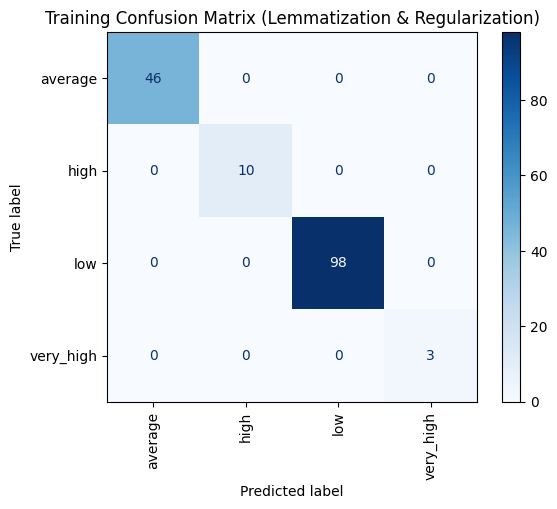

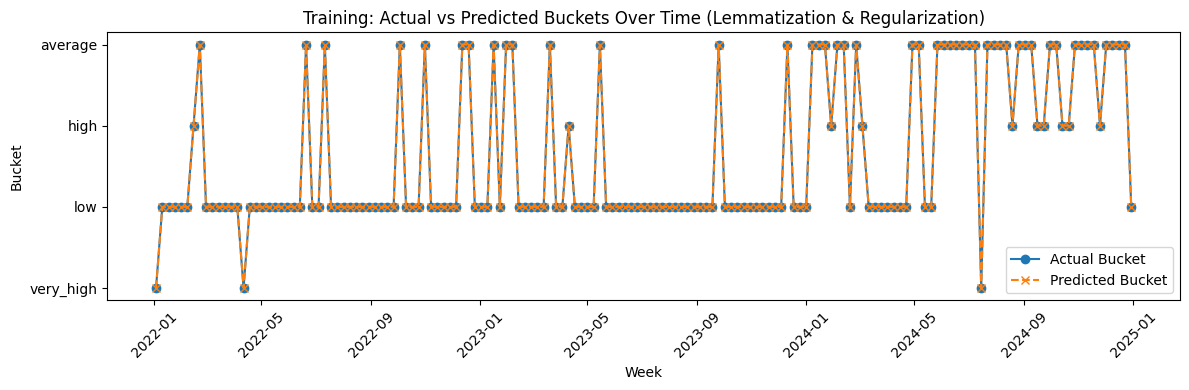

--- Lemmatization & Regularization Testing Set Results ---
F1-Weighted Score: 0.4068 (Primary Indicator)
F1-Macro Score:    0.1695 (Minority Class Performance)
Accuracy:          0.5000 (Raw Correctness)


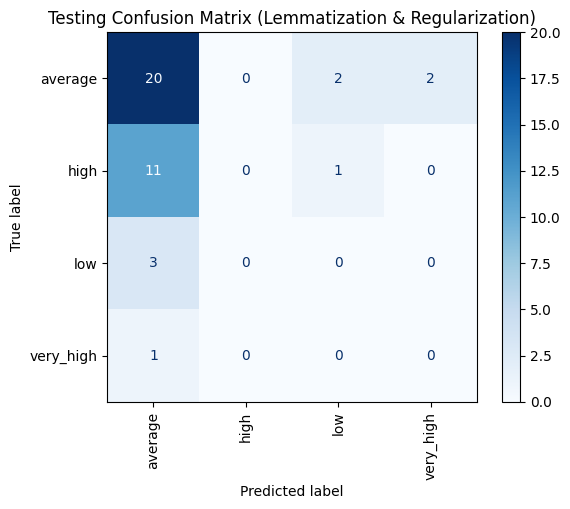

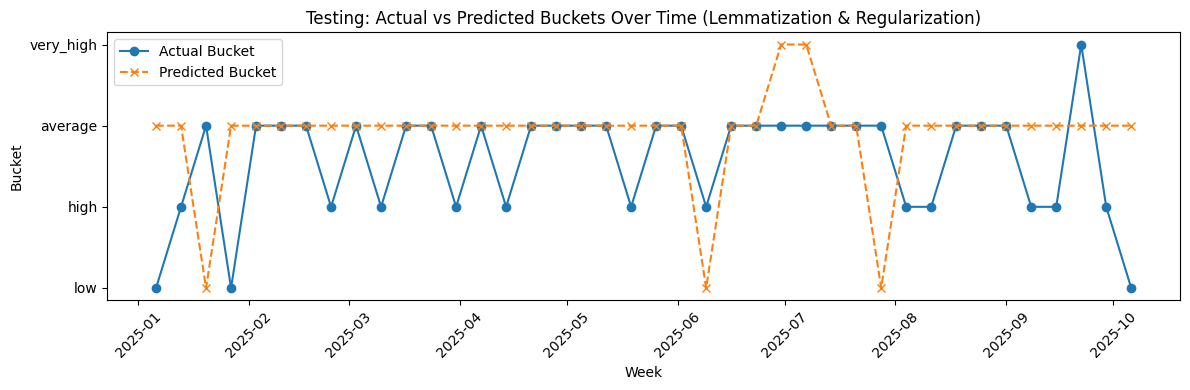

In [ ]:
best_reg_C = reg_params['clf__C']

regPipeline = Pipeline([
    ('clf', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=500,
        penalty='l2',
        class_weight = 'balanced', # Added based on our identification of class imbalances
        C=best_reg_C,
        random_state=42
    ))
])

clf_lemma_reg= train_evaluate_model_2(
    train_df_lemma,
    test_df_lemma,
    X_train_lemma,
    y_train_lemma,
    X_test_lemma,
    y_test_lemma,
    regPipeline,
    model_name="Lemmatization & Regularization",
    plots=True
)


### **TF-IDF Vectorization, Logistic Regression - Lemmatization, PCA, & Regularization**

In [ ]:
pca_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=42)),
    ('clf', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=500,
        penalty='l2',
        class_weight='balanced', # Added based on our analysis of imbalance
        random_state=42
    ))
])

pca_param_grid = {
    'pca__n_components': [5, 10, 15, 20, 25],  # Test different levels of dimensionality reduction
    'clf__C': [0.01, 0.1, 1, 10]
}

pca_reg_params = perform_grid_search(pca_reg_pipeline, pca_param_grid, X_train_lemma, y_train_lemma, split_num = 5)

Starting Grid Search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- Grid Search Complete ---
Best Score found: 0.5992
Best Hyperparameters: {'clf__C': 0.01, 'pca__n_components': 5}


--- Lemmatization, Regularization, & PCA Training Set Results ---
F1-Weighted Score: 0.5516 (Primary Indicator)
F1-Macro Score:    0.3880 (Minority Class Performance)
Accuracy:          0.4968 (Raw Correctness)


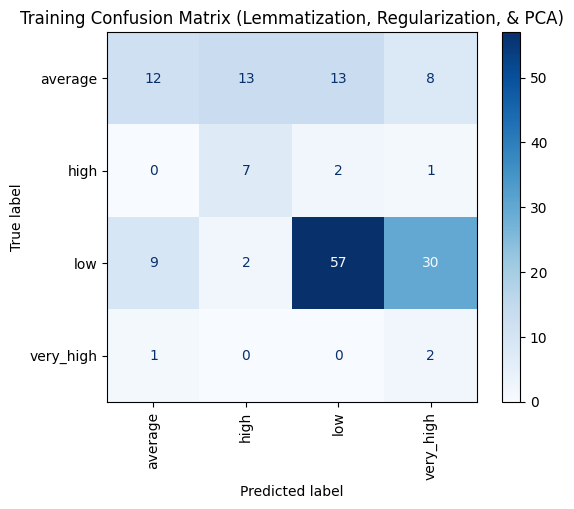

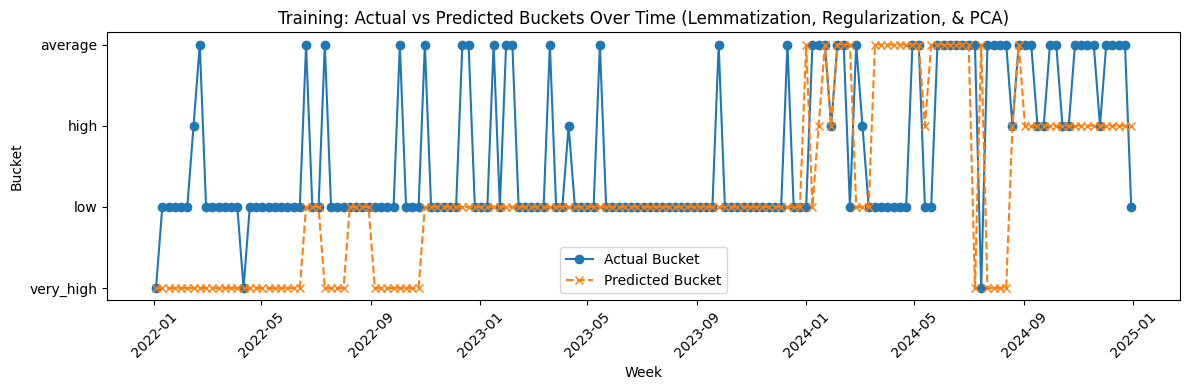

--- Lemmatization, Regularization, & PCA Testing Set Results ---
F1-Weighted Score: 0.4671 (Primary Indicator)
F1-Macro Score:    0.2113 (Minority Class Performance)
Accuracy:          0.5500 (Raw Correctness)


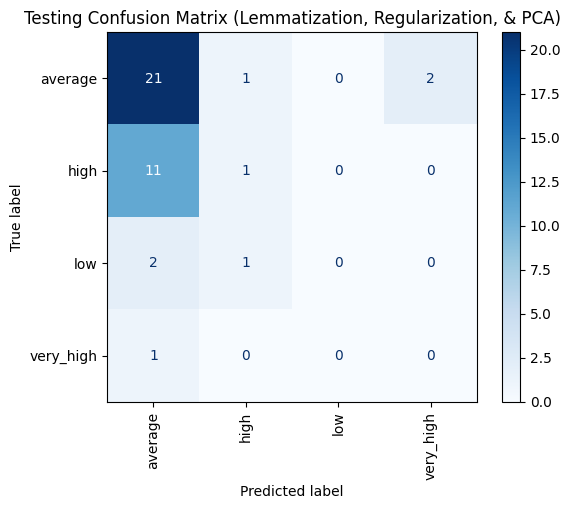

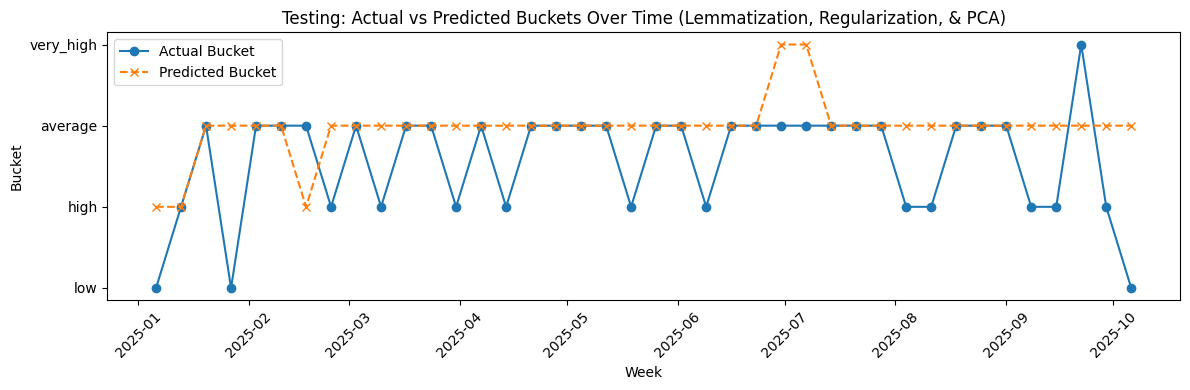

In [ ]:
best_n_components_pca = pca_reg_params['pca__n_components']
best_pca_reg_C = pca_reg_params['clf__C']

pcaRegPipeline = Pipeline([
    ('scaler', StandardScaler()),
    # Use the best n_components found
    ('pca', PCA(n_components=best_n_components_pca, random_state=42)),
    ('clf', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=500,
        penalty='l2',
        class_weight='balanced',
        # Use the best C value found
        C=best_pca_reg_C,
        random_state=42
    ))
])

clf_lemma_reg_pca= train_evaluate_model_2(
    train_df_lemma,
    test_df_lemma,
    X_train_lemma,
    y_train_lemma,
    X_test_lemma,
    y_test_lemma,
    pcaRegPipeline,
    model_name="Lemmatization, Regularization, & PCA",
    plots=True
)


## Comments

In [ ]:
print("Original Target Distribution:")
display(pd.DataFrame(y_train_lemma).value_counts(normalize=True))

print("\nTest Target Distribution:")
display(pd.DataFrame(y_test_lemma).value_counts(normalize=True))


Original Target Distribution:


,proportion
0,
low,0.624204
average,0.292994
high,0.063694
very_high,0.019108



Test Target Distribution:


,proportion
0,
average,0.600
high,0.300
low,0.075
very_high,0.025


Looking at the dataset as a whole, we can see how there was a marked change in the number of alerts between April 2024 and June 2024.

This temporal change could contribute to some of the performance issues, as the data is drifting over time, meaning that the model was trained on data that is not representative of more recent conditions.

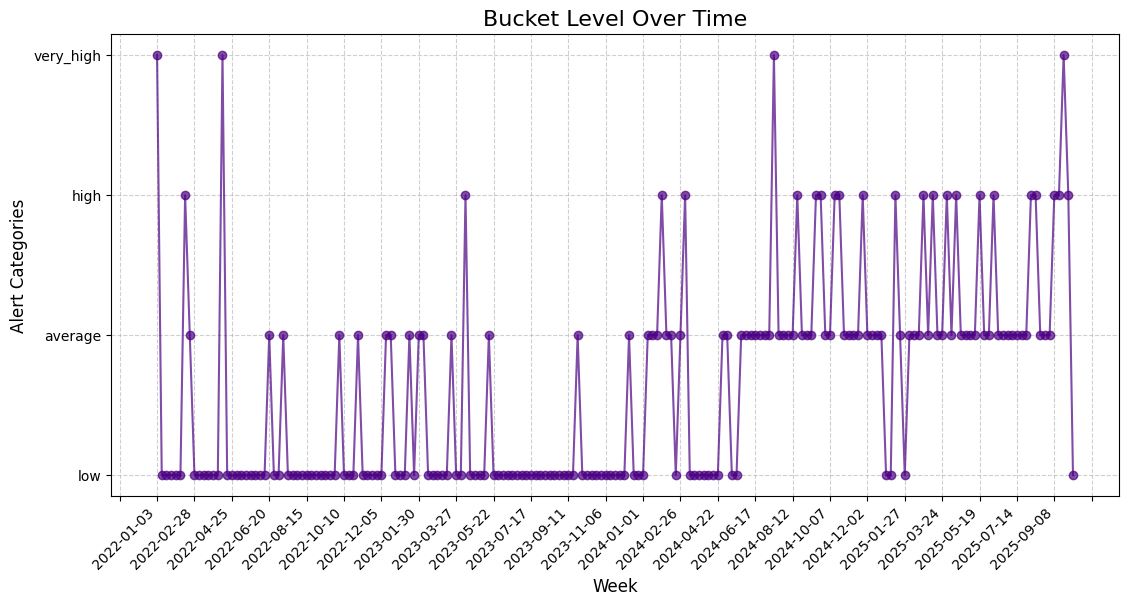

In [ ]:
plt.figure(figsize=(13,6))
plt.plot(baseline_alerts_df['WEEK'], baseline_alerts_df['bucket_encoded'], marker='o', linestyle='-', color='indigo', alpha=0.7)
plt.title('Bucket Level Over Time', fontsize=16)
plt.ylabel('Alert Categories', fontsize=12)
plt.xlabel('Week', fontsize=12)
# Get the current axes
ax = plt.gca()
# Set the maximum number of ticks you want visible on the x-axis
n_ticks_to_show = 30
ax.xaxis.set_major_locator(MaxNLocator(n_ticks_to_show))
plt.yticks(list(bucket_map.values()), list(bucket_map.keys()))
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
y_train_series = pd.Series(y_train_lemma)
y_test_series = pd.Series(y_test_lemma)

# For Training Data
train_df = pd.DataFrame(y_train_series.value_counts(normalize=True)).reset_index()
train_df.columns = ['Bucket', 'Proportion']
train_df['Dataset'] = 'Training Data'

# For Testing Data
test_df = pd.DataFrame(y_test_series.value_counts(normalize=True)).reset_index()
test_df.columns = ['Bucket', 'Proportion']
test_df['Dataset'] = 'Testing Data'

# Concatenate for the final plotting DataFrame
combined_df = pd.concat([train_df, test_df], ignore_index=True)

categories = ['low', 'average', 'high', 'very_high']
combined_df['Bucket'] = pd.Categorical(combined_df['Bucket'], categories=categories, ordered=True)
combined_df = combined_df.sort_values('Bucket')

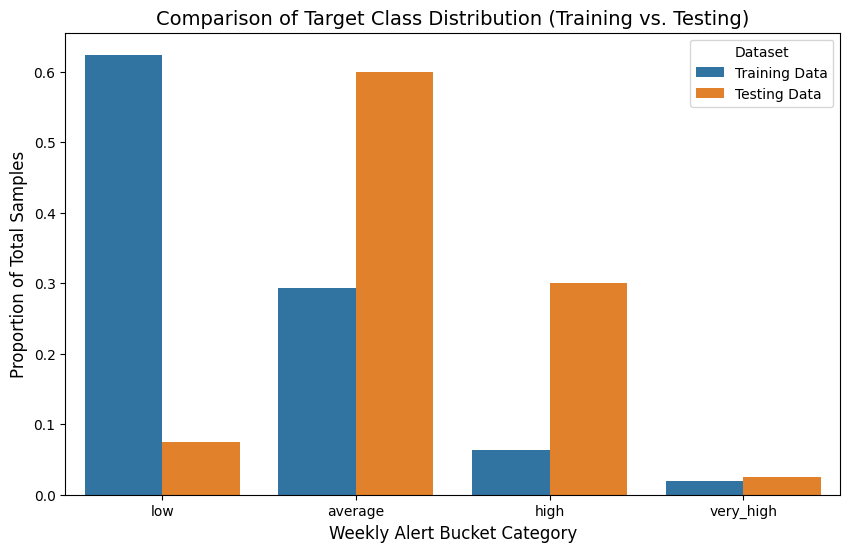

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Bucket', y='Proportion', hue='Dataset', data=combined_df)

plt.title('Comparison of Target Class Distribution (Training vs. Testing)', fontsize=14)
plt.xlabel('Weekly Alert Bucket Category', fontsize=12)
plt.ylabel('Proportion of Total Samples', fontsize=12)
plt.show()